# 4. Build Theory‑Aligned Composites & Indices (Bridge to Hypotheses) - IMPROVED VERSION

This notebook turns your **taxonomy** into *hypothesis‑testing machinery* by constructing **theory‑aligned composites (A–S)** from `taxonomy_main_id` (and optional topic-level filters), then producing:

- **Book-level indices** (global theme emphasis)
- **Optional segment-level indices** (begin/middle/end) if segment topic probabilities are available
- **Normalization** (raw shares, z-scores, log-ratios)
- **Reliability checks** (Cronbach's α, item correlations, segment consistency)
- **Exports** into the stage output directory for downstream hypothesis testing

**Version:** v4 (Improved with bug fixes, better design, robust edge case handling)
**Generated:** 2026-01-08

## Key Improvements
- ✅ Fixed `CompositeSpec` missing fields (`min_topics`, `allow_global_fallback`)
- ✅ Added `small_group_policy` and relaxation ladder for small composites
- ✅ Added `SMALL_COMPOSITE_POLICY` to drop sparse/empty composites
- ✅ Safe log-ratio handling (prevents divide-by-zero warnings)
- ✅ Auto-discovery of segment topic probability files
- ✅ Better code organization with clearly numbered cells

---
## Expected input tables

### `topic_lookup.parquet` (topic → taxonomy)
Required columns:
- `topic_id`, `taxonomy_main_id`, `taxonomy_main_name`
- Optional: `taxonomy_is_noise`, `label_is_noise`, `taxonomy_confidence`
- Optional: `primary_categories`, `secondary_categories`, `label`, `keywords` (for topic filters)

### `book_topic_probs.parquet` (book × topic mixture)
Required columns:
- `book_id`, `topic_id`, `prob`

### `topic_author_dominance.parquet` (topic diagnostics)
Optional columns used:
- `topic_id`, `author_dominance_flag`

### `topic_health_table.parquet` (topic diagnostics)
Optional columns used:
- `topic_id`, `prevalence`

### Optional: `segment_topic_probs.parquet` (book × segment × topic mixture)
If present, required columns:
- `book_id`, `segment` (or `segment_id`), `topic_id`, `prob`


In [38]:
# ==============================
# CONFIG
# ==============================
from pathlib import Path
import pandas as pd
import numpy as np

# ---- REQUIRED INPUTS (stage10) ----
TOPIC_LOOKUP_PATH = Path(
    "/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/data_preparation/taxonomy_radway_eda/topic_lookup.parquet"
)
AUTHOR_DOMINANCE_PATH = Path(
    "/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/topic_analysis_all_368/tables/topic_author_dominance.parquet"
)
BOOK_TOPIC_PROBS_PATH = Path(
    "/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/data_preparation/topic_probabilities/book_topic_probs.parquet"
)
TOPIC_HEALTH_PATH = Path(
    "/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/topic_analysis_all_368/tables/topic_health_table.parquet"
)

# ---- OPTIONAL: Segment / temporal topic probabilities (begin/middle/end) ----
SEGMENT_TOPIC_PROBS_PATH = Path(
    "/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/data_preparation/topic_probabilities/tertile_topic_probs.parquet"
)

# ---- OUTPUT DIR ----
OUTPUT_DIR = Path(
    "/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_INDICES_DIR = OUTPUT_DIR / "indices"
OUT_INDICES_DIR.mkdir(parents=True, exist_ok=True)

# ==============================
# FILTERS / DATA QUALITY
# ==============================
EXCLUDE_NOISE_TOPICS = True             # uses topic_lookup.taxonomy_is_noise + label_is_noise where available
EXCLUDE_AUTHOR_DOMINANT = True          # uses author_dominance.author_dominance_flag
AUTHOR_FLAG_EXCLUDE = ("high",)         # tuple of flags to exclude
MIN_PREVALENCE = None                   # e.g. 0.05 to exclude very rare topics; None disables

# ==============================
# SMALL COMPOSITE CONTROLS ✅ NEW
# ==============================
MIN_TOPICS_PER_COMPOSITE = 4            # below this => "sparse" (still computable, but flagged)
SMALL_COMPOSITE_POLICY = "drop"         # "keep" or "drop"
# keep = compute index anyway (singletons become 1-topic indices)
# drop = remove sparse/empty composites from index matrices + derived indices/log-ratios

# ==============================
# NORMALIZATION / COMPOSITION
# ==============================
EPSILON = 1e-6

# Z-score over books (recommended for regressions)
MAKE_ZSCORES = True

# Log-ratio contrasts (recommended for compositional "balance" hypotheses)
MAKE_LOG_RATIOS = True


In [39]:
# ==============================
# CELL 2 — LOAD INPUTS
# ==============================
from pathlib import Path
import pandas as pd
import numpy as np

def _read_parquet(path: Path) -> pd.DataFrame:
    if path is None:
        raise ValueError("Path is None")
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_parquet(path)

# Load inputs
topic_lookup = _read_parquet(TOPIC_LOOKUP_PATH)
book_topic_probs = _read_parquet(BOOK_TOPIC_PROBS_PATH)

author_dom = None
if AUTHOR_DOMINANCE_PATH.exists():
    author_dom = _read_parquet(AUTHOR_DOMINANCE_PATH)

topic_health = None
if TOPIC_HEALTH_PATH.exists():
    topic_health = _read_parquet(TOPIC_HEALTH_PATH)

print("✓ Loaded topic_lookup:", topic_lookup.shape)
print("✓ Loaded book_topic_probs:", book_topic_probs.shape)
print("✓ Loaded author_dominance:", None if author_dom is None else author_dom.shape)
print("✓ Loaded topic_health:", None if topic_health is None else topic_health.shape)

# Basic schema checks
for col in ["topic_id", "taxonomy_main_id", "taxonomy_main_name"]:
    if col not in topic_lookup.columns:
        raise KeyError(f"topic_lookup missing required column: {col}")

for col in ["book_id", "topic_id", "prob"]:
    if col not in book_topic_probs.columns:
        raise KeyError(f"book_topic_probs missing required column: {col}")

# Ensure types
topic_lookup["topic_id"] = pd.to_numeric(topic_lookup["topic_id"], errors="raise").astype(int)
book_topic_probs["book_id"] = book_topic_probs["book_id"].astype(str)
book_topic_probs["topic_id"] = pd.to_numeric(book_topic_probs["topic_id"], errors="raise").astype(int)
book_topic_probs["prob"] = pd.to_numeric(book_topic_probs["prob"], errors="coerce").fillna(0.0)

# Print taxonomy coverage
print("\nTaxonomy main_id coverage (n topics):")
coverage = (
    topic_lookup.dropna(subset=["taxonomy_main_id"])
    .groupby(["taxonomy_main_id", "taxonomy_main_name"])["topic_id"]
    .nunique()
    .sort_values(ascending=False)
)
print(coverage.head(20))


✓ Loaded topic_lookup: (369, 21)
✓ Loaded book_topic_probs: (33856, 3)
✓ Loaded author_dominance: (324, 15)
✓ Loaded topic_health: (343, 8)

Taxonomy main_id coverage (n topics):
taxonomy_main_id  taxonomy_main_name                             
4.2               Bonding, Everyday Intimacy & Growth                71
4.4               Conflict, Distance & Breakup Threats               61
3.2               Negative Emotions & Distress                       36
5.1               Family & Kinship                                   20
2.2               Kissing & Non-Explicit Affection                   20
2.3               Explicit Sexual Acts                               19
4.3               Secrets, Misunderstandings & Hidden Information    19
6.1               Hero's Elite Work & Business World                 16
2.1               Attraction & Sexual Tension                        14
8.1               Domestic Spaces & Routines                         13
3.1               Positive Emotions

In [40]:
# ==============================
# CELL 3 (REVISED) — COMPOSITES WITH SPLITS & RELAXED FILTERS
# ==============================
from typing import Dict

# Dependency check
missing = []
if "CompositeSpec" not in globals():
    missing.append("CompositeSpec")
if "DEFAULT_MIN_TOPICS" not in globals():
    missing.append("DEFAULT_MIN_TOPICS")
if missing:
    raise NameError(
        f"Missing: {', '.join(missing)}. Run Cell 4 (GATING) first."
    )

COMPOSITES: Dict[str, CompositeSpec] = {
    # ============================================================
    # SPLIT: A_reassurance_commitment (was α=-0.22, 80 topics)
    # ============================================================
    "A1_commitment_vows": CompositeSpec(
        name="A1) Commitment & Vows",
        taxonomy_main_ids=["4.5"],  # Reconciliation, Commitments & HEA
        include_name_regex=r"(commit|promise|forever|vow|marry|marriage|wedding|proposal|ring|engagement)",
        note="explicit commitment language (marriage plot)",
        min_topics=3,
        allow_global_fallback=False,
    ),
    "A2_emotional_safety": CompositeSpec(
        name="A2) Emotional Safety & Reassurance",
        taxonomy_main_ids=["3.1"],  # Positive Emotions & Security
        include_name_regex=r"(safe|reassur|comfort|calm|peace|secur|trust|relax|gentle)",
        note="safety/trust/comfort affect",
        min_topics=4,
        allow_global_fallback=False,
    ),
    "A3_everyday_tenderness": CompositeSpec(
        name="A3) Everyday Tenderness",
        taxonomy_main_ids=["4.2"],  # Bonding, Everyday Intimacy & Growth
        exclude_name_regex=r"(vow|promise|commit|marry)",  # exclude formal commitment
        include_name_regex=r"(tender|gentle|care|affection|warmth|close|bond)",
        note="daily affectionate bonding (not formal vows)",
        min_topics=6,
        allow_global_fallback=False,
    ),
    
    # ============================================================
    # SPLIT: B_mutual_intimacy (was α=-0.15, 106 topics)
    # ============================================================
    "B1_attraction_chemistry": CompositeSpec(
        name="B1) Attraction & Chemistry",
        taxonomy_main_ids=["2.1", "2.2"],  # Attraction + Kissing (no 4.2 bonding bleed)
        exclude_name_regex=r"\\b(penetrat|clit|pussy|cock|orgasm|anal|fuck)\\b",
        note="sexual tension + kissing (pre-sex intimacy)",
        min_topics=8,
        allow_global_fallback=False,
    ),
    "B2_emotional_intimacy": CompositeSpec(
        name="B2) Emotional Intimacy",
        taxonomy_main_ids=["3.1", "4.2"],  # Positive emotions + bonding
        exclude_name_regex=r"\\b(penetrat|clit|pussy|cock|orgasm|anal|fuck|kiss|tongue)\\b",
        include_name_regex=r"(share|open|vulner|understand|connect|close|trust|reveal)",
        note="emotional closeness (not physical)",
        min_topics=8,
        allow_global_fallback=False,
    ),
    
    # ============================================================
    # KEEP: C_explicit_eroticism (α=-0.53 is expected — different acts trade off)
    # ============================================================
    "C_explicit_eroticism": CompositeSpec(
        name="C) Explicit Eroticism",
        taxonomy_main_ids=["2.3"],
        note="explicit sexual act language (heterogeneous by design)",
        min_topics=8,
        allow_global_fallback=False,
    ),
    
    # ============================================================
    # KEEP: D, E (functioning composites)
    # ============================================================
    "D_power_wealth_luxury": CompositeSpec(
        name="D) Power / Wealth / Luxury",
        taxonomy_main_ids=["5.2", "5.3", "5.1"],
        note="billionaire-world saturation",
        min_topics=10,
        allow_global_fallback=False,
    ),
    "E_coercion_brutality_danger": CompositeSpec(
        name="E) Coercion / Brutality / Danger",
        taxonomy_main_ids=["7.2", "3.2"],
        include_name_regex=r"(threat|violence|weapon|kidnap|coerc|abuse|trauma|tortur|panic|fear|gun|danger|attack)",
        note="threat + coercion + traumatic texture",
        min_topics=6,
        allow_global_fallback=False,
    ),
    
    # ============================================================
    # SPLIT: F_angst_negative_affect (was α=-0.25, 55 topics)
    # ============================================================
    "F1_sadness_grief": CompositeSpec(
        name="F1) Sadness & Grief",
        taxonomy_main_ids=["3.2"],
        include_name_regex=r"(sad|cry|tear|grief|mourn|sorrow|depress|melanchol)",
        note="sadness affect cluster",
        min_topics=4,
        allow_global_fallback=False,
    ),
    "F2_anger_frustration": CompositeSpec(
        name="F2) Anger & Frustration",
        taxonomy_main_ids=["3.2", "3.3"],
        include_name_regex=r"(angry|anger|rage|furious|frustrat|irritat|resent|bitter)",
        note="anger/resentment affect",
        min_topics=4,
        allow_global_fallback=False,
    ),
    "F3_anxiety_worry": CompositeSpec(
        name="F3) Anxiety & Worry",
        taxonomy_main_ids=["3.2", "3.4"],
        include_name_regex=r"(anxious|anxiety|worry|nervous|stress|tension|uncertain|doubt)",
        note="anxiety/worry affect",
        min_topics=4,
        allow_global_fallback=False,
    ),
    
    # ============================================================
    # RELAXED: G, L, M (was empty — broader patterns)
    # ============================================================
    "G_courtship_rituals_gifts": CompositeSpec(
        name="G) Courtship Rituals / Gifts",
        taxonomy_main_ids=["5.3", "8.1", "8.2"],  # expanded to include setting topics
        include_name_regex=r"(gift|flower|dinner|date|restaurant|party|celebrat|surprise|romantic)",  # broader
        exclude_name_regex=r"(work|office|business|meeting)",  # avoid work dinners
        note="ritualized romance behaviors (RELAXED)",
        min_topics=4,
        allow_global_fallback=True,  # enable global fallback for sparse pattern
    ),
    "L_vices_addictions": CompositeSpec(
        name="L) Vices / Addictions",
        taxonomy_main_ids=["6.2", "6.3", "3.2"],  # added 3.2 for distress
        include_name_regex=r"(drink|alcohol|wine|bottle|bar|drunk|hangover|smoke|cigarette|drug|addict)",  # MUCH broader
        note="substance use & self-destructive risk (RELAXED)",
        min_topics=3,  # lowered threshold
        allow_global_fallback=True,
    ),
    "M_health_recovery_growth": CompositeSpec(
        name="M) Health / Recovery / Growth",
        taxonomy_main_ids=["6.5", "4.2"],  # added 4.2 for caretaking
        include_name_regex=r"(hospital|doctor|nurse|clinic|therap|medical|injur|pain|hurt|heal|recover|care|aid)",  # broader
        note="healing and protective caretaking (RELAXED)",
        min_topics=3,
        allow_global_fallback=True,
    ),
    
    # ============================================================
    # KEEP: H_domestic, I_humor, J_social, K_professional (all OK)
    # ============================================================
    "H_domestic_nesting": CompositeSpec(
        name="H) Domestic Nesting (Home-as-Refuge)",
        taxonomy_main_ids=["4.2", "5.2", "8.1"],
        note="nest-building and everyday shared life",
        min_topics=10,
        allow_global_fallback=False,
    ),
    "I_humor_lightness": CompositeSpec(
        name="I) Humor / Lightness",
        taxonomy_main_ids=["3.1", "4.2", "2.2"],
        include_name_regex=r"(laugh|joke|teas|banter|sarcasm|funny|smil|humor|wit|playful)",
        note="comic relief / breezy tone proxies",
        min_topics=6,
        allow_global_fallback=True,
    ),
    "J_social_support_kin": CompositeSpec(
        name="J) Social Support / Kin",
        taxonomy_main_ids=["4.3", "4.4", "4.5", "5.1"],
        include_name_regex=r"(family|friend|community|parent|child|sister|brother|mother|father)",
        note="stable social buffering around the couple",
        min_topics=8,
        allow_global_fallback=False,
    ),
    "K_professional_intrusion": CompositeSpec(
        name="K) Professional Intrusion",
        taxonomy_main_ids=["6.1", "6.2", "6.3", "6.5"],
        include_name_regex=r"(work|office|deal|contract|meeting|board|law|court|authority|boss|business|corporate|boardroom)",
        note="workplace and institutional texture",
        min_topics=6,
        allow_global_fallback=False,
    ),
    
    # ============================================================
    # KEEP: N, O, Q, S (all functioning)
    # ============================================================
    "N_separation_reunion": CompositeSpec(
        name="N) Separation / Reunion",
        taxonomy_main_ids=["4.4", "4.5"],
        include_name_regex=r"(break|leave|separat|reconcil|reun|return|distance|apart|forgiv|sorry)",
        note="break → return → repair signals",
        min_topics=8,
        allow_global_fallback=False,
    ),
    "O_aesthetics_appearance": CompositeSpec(
        name="O) Aesthetics / Appearance",
        taxonomy_main_ids=["1.1", "5.3"],
        include_name_regex=r"(dress|suit|clothes|hair|makeup|groom|heels|beautiful|handsome|stubble|lingerie)",
        note="look-and-status signaling",
        min_topics=4,
        allow_global_fallback=False,
    ),
    "Q_miscommunication": CompositeSpec(
        name="Q_miscommunication",
        taxonomy_main_ids=["4.1", "4.3"],
        include_name_regex=r"(secret|misunderstand|miscommunicat|silent|argument|unclear|confus|lie)",
        note="secrets, misunderstandings, silence",
        min_topics=6,
        allow_global_fallback=False,
    ),
    "Q_repair": CompositeSpec(
        name="Q_repair",
        taxonomy_main_ids=["4.5", "4.2", "3.1"],
        include_secondary_cats_any=["activity:apologizing", "activity:saying_sorry", "activity:love_confession", "activity:vowing"],
        note="apologies, forgiveness, reconciliation",
        min_topics=4,
        allow_global_fallback=False,
    ),
    
    # ============================================================
    # SPLIT: R_protectiveness (α=-0.72, 15 topics — WORST OFFENDER)
    # ============================================================
    "R1_protective_caretaking": CompositeSpec(
        name="R1) Protective Caretaking",
        taxonomy_main_ids=["3.1", "4.2"],
        include_name_regex=r"(protect|safe|care|help|comfort|calm|rescu|soothe)",
        exclude_name_regex=r"(guard|security|threat|danger)",  # exclude protective violence
        note="tender protective care (not alpha guarding)",
        min_topics=4,
        allow_global_fallback=False,
    ),
    "R2_jealous_guarding": CompositeSpec(
        name="R2) Jealous Guarding",
        taxonomy_main_ids=["3.3", "4.4"],
        include_name_regex=r"(guard|mine|possess|territorial|control|jealous|watch|danger)",
        note="possessive protective aggression",
        min_topics=4,
        allow_global_fallback=False,
    ),
    
    # Keep original R_jealousy for continuity
    "R_jealousy_possessiveness": CompositeSpec(
        name="R_jealousy/possessiveness",
        taxonomy_main_ids=["3.3", "4.4"],
        include_name_regex=r"(jealous|possess|mine|territorial|claim|obsess|control|stalk)",
        note="jealous/possessive conflict",
        min_topics=4,
        allow_global_fallback=False,
    ),
    
    # ============================================================
    # KEEP: S (best reliability, α=0.40)
    # ============================================================
    "S_scene_anchors": CompositeSpec(
        name="S) Scene Anchors (setting-rich)",
        taxonomy_main_ids=["5.3", "8.1", "8.2"],
        note="setting/objects/time/atmosphere topics for qualitative sampling",
        min_topics=8,
        allow_global_fallback=False,
    ),
}

print(f"✓ Defined {len(COMPOSITES)} composites (includes splits of A, B, F, R)")
print(f"  - Split A → A1, A2, A3")
print(f"  - Split B → B1, B2")
print(f"  - Split F → F1, F2, F3")
print(f"  - Split R_protectiveness → R1, R2")
print(f"  - Relaxed G, L, M (broader regex + global fallback)")

✓ Defined 26 composites (includes splits of A, B, F, R)
  - Split A → A1, A2, A3
  - Split B → B1, B2
  - Split F → F1, F2, F3
  - Split R_protectiveness → R1, R2
  - Relaxed G, L, M (broader regex + global fallback)


In [41]:
# ==============================
# CELL 4 — GATING + COMPOSITE SELECTION
# ==============================
import re
from dataclasses import dataclass, field, replace
from typing import List, Optional, Dict, Tuple, Literal

# ---- small-group policy defaults ----
DEFAULT_MIN_TOPICS = 4
SMALL_GROUP_POLICY: Literal["disable", "relax"] = "relax"
# "disable": if composite ends up with < min_topics -> composite_topics[key]=[] and index will be 0 everywhere
# "relax":   progressively relax constraints until >= min_topics (or give up -> disable)

def _split_csvish(x):
    if pd.isna(x) or x is None:
        return []
    if isinstance(x, (list, tuple, set)):
        return list(x)
    return [s.strip() for s in str(x).split(",") if s.strip()]

def combined_text(df: pd.DataFrame) -> pd.Series:
    cols = ["label", "taxonomy_main_name", "primary_categories", "secondary_categories", "keywords", "scene_summary"]
    out = pd.Series("", index=df.index)
    for c in cols:
        if c in df.columns:
            out = out + " " + df[c].fillna("").astype(str)
    return out

def _safe_regex(pattern: str) -> str:
    """
    Avoid pandas warning about capturing groups by converting ( ... ) to (?: ... )
    unless it's already a non-capturing group or a special group.
    """
    if not pattern:
        return pattern
    if re.search(r"\((?!\?)", pattern):
        return re.sub(r"\((?!\?)", r"(?:", pattern)
    return pattern

def regex_gate(df: pd.DataFrame, pattern: Optional[str]) -> pd.DataFrame:
    if not pattern:
        return df
    txt = combined_text(df)
    pat = _safe_regex(pattern)
    return df[txt.str.contains(pat, case=False, regex=True, na=False)]

def build_topic_gate_table(topic_lookup: pd.DataFrame,
                           author_dom: Optional[pd.DataFrame],
                           topic_health: Optional[pd.DataFrame]) -> pd.DataFrame:
    df = topic_lookup.copy()

    # Noise flags
    if "taxonomy_is_noise" in df.columns:
        df["taxonomy_is_noise"] = df["taxonomy_is_noise"].astype("boolean").fillna(False).astype(bool)
    else:
        df["taxonomy_is_noise"] = False

    if "label_is_noise" in df.columns:
        df["label_is_noise"] = df["label_is_noise"].astype("boolean").fillna(False).astype(bool)
    else:
        df["label_is_noise"] = False

    # Author dominance
    if author_dom is not None and "topic_id" in author_dom.columns:
        keep_cols = ["topic_id"] + [c for c in ["author_dominance_flag","is_author_driven","top_author_share","prevalence"] if c in author_dom.columns]
        ad = author_dom[keep_cols].copy()
        df = df.merge(ad, on="topic_id", how="left")
    else:
        df["author_dominance_flag"] = None

    # Topic health
    if topic_health is not None and "topic_id" in topic_health.columns:
        keep_cols = ["topic_id"] + [c for c in ["prevalence","mass","concentration_ratio"] if c in topic_health.columns]
        th = topic_health[keep_cols].copy()
        df = df.merge(th, on="topic_id", how="left", suffixes=("", "_health"))
    else:
        df["prevalence"] = None

    # Parsed categories
    df["primary_cat_list"] = df["primary_categories"].apply(_split_csvish) if "primary_categories" in df.columns else [[] for _ in range(len(df))]
    df["secondary_cat_list"] = df["secondary_categories"].apply(_split_csvish) if "secondary_categories" in df.columns else [[] for _ in range(len(df))]

    # Text columns present
    for c in ["taxonomy_main_name","label","keywords","scene_summary","primary_categories","secondary_categories"]:
        if c not in df.columns:
            df[c] = ""
        df[c] = df[c].fillna("").astype(str)

    return df

gate = build_topic_gate_table(topic_lookup, author_dom, topic_health)

@dataclass
class CompositeSpec:
    name: str
    taxonomy_main_ids: List[str] = field(default_factory=list)
    include_name_regex: Optional[str] = None
    exclude_name_regex: Optional[str] = None
    include_primary_cats_any: List[str] = field(default_factory=list)
    exclude_primary_cats_any: List[str] = field(default_factory=list)
    include_secondary_cats_any: List[str] = field(default_factory=list)
    exclude_secondary_cats_any: List[str] = field(default_factory=list)
    note: str = ""
    min_topics: int = DEFAULT_MIN_TOPICS
    allow_global_fallback: bool = False  # if True, when too small we may apply regex globally (outside taxonomy_main_ids)

def _make_regex_non_capturing(pattern: str) -> str:
    """
    pandas warns when regex has capturing groups. Convert bare (...) -> (?:...)
    (keeps behavior for simple alternations; avoids warning).
    """
    if not pattern:
        return pattern
    if re.search(r"\((?!\?)", pattern):
        return re.sub(r"\((?!\?)", r"(?:", pattern)
    return pattern

def _apply_base_filters(
    df: pd.DataFrame,
    exclude_taxonomy_noise: bool,
    exclude_label_noise: bool,
    exclude_author_dominant: bool,
    author_flag_exclude: Tuple[str, ...],
    min_prevalence: Optional[float],
) -> pd.DataFrame:
    if exclude_taxonomy_noise and "taxonomy_is_noise" in df.columns:
        df = df[~df["taxonomy_is_noise"]]
    if exclude_label_noise and "label_is_noise" in df.columns:
        df = df[~df["label_is_noise"]]
    if exclude_author_dominant and "author_dominance_flag" in df.columns:
        df = df[~df["author_dominance_flag"].astype(str).str.lower().isin([a.lower() for a in author_flag_exclude])]
    if (min_prevalence is not None) and ("prevalence" in df.columns):
        df = df[df["prevalence"].fillna(0.0) >= float(min_prevalence)]
    return df

def _apply_spec_filters(df: pd.DataFrame, spec: CompositeSpec) -> pd.DataFrame:
    # regex include/exclude over combined_text
    if spec.include_name_regex:
        df = regex_gate(df, spec.include_name_regex)
    if spec.exclude_name_regex:
        txt = combined_text(df)
        safe_ex = _make_regex_non_capturing(spec.exclude_name_regex)
        df = df[~txt.str.contains(safe_ex, case=False, regex=True, na=False)]

    # category membership filters
    if spec.include_primary_cats_any:
        want = set(spec.include_primary_cats_any)
        df = df[df["primary_cat_list"].apply(lambda xs: any(x in want for x in xs))]
    if spec.exclude_primary_cats_any:
        bad = set(spec.exclude_primary_cats_any)
        df = df[~df["primary_cat_list"].apply(lambda xs: any(x in bad for x in xs))]

    if spec.include_secondary_cats_any:
        want2 = set(spec.include_secondary_cats_any)
        df = df[df["secondary_cat_list"].apply(lambda xs: any(x in want2 for x in xs))]
    if spec.exclude_secondary_cats_any:
        bad2 = set(spec.exclude_secondary_cats_any)
        df = df[~df["secondary_cat_list"].apply(lambda xs: any(x in bad2 for x in xs))]

    return df

def _ensure_topic_id(df: pd.DataFrame, gate_df: pd.DataFrame) -> pd.DataFrame:
    if "topic_id" in df.columns:
        return df
    if "topic_id" in gate_df.columns:
        if len(df) > 0:
            df = df.copy()
            df["topic_id"] = gate_df.loc[df.index, "topic_id"].values
            return df
        df = df.copy()
        df["topic_id"] = pd.Series(dtype=gate_df["topic_id"].dtype)
        return df
    raise ValueError("topic_id column missing from gate_df")

def select_topics_for_composite(
    gate_df: pd.DataFrame,
    spec: CompositeSpec,
    exclude_taxonomy_noise: bool = True,
    exclude_label_noise: bool = True,
    exclude_author_dominant: bool = True,
    author_flag_exclude: Tuple[str, ...] = ("high",),
    min_prevalence: Optional[float] = None,
    small_group_policy: Literal["disable", "relax"] = "relax",
) -> Tuple[pd.DataFrame, str]:
    """
    Returns (selected_df, status_string)
    status_string is useful for audit: "ok", "relaxed:...", "disabled:..."
    """
    base = gate_df.copy()

    # Apply taxonomy_main_ids restriction first (primary semantic anchor)
    if spec.taxonomy_main_ids:
        base = base[base["taxonomy_main_id"].astype(str).isin([str(x) for x in spec.taxonomy_main_ids])]

    base = _apply_base_filters(
        base,
        exclude_taxonomy_noise=exclude_taxonomy_noise,
        exclude_label_noise=exclude_label_noise,
        exclude_author_dominant=exclude_author_dominant,
        author_flag_exclude=author_flag_exclude,
        min_prevalence=min_prevalence,
    )

    # Apply full spec filters
    sel = _apply_spec_filters(base, spec)
    sel = _ensure_topic_id(sel, gate_df)

    # If enough topics, done
    if sel["topic_id"].nunique() >= int(spec.min_topics):
        return sel, "ok"

    # Handle small groups
    if small_group_policy == "disable":
        empty = sel.iloc[0:0].copy()
        return empty, f"disabled: n<{spec.min_topics}"

    # small_group_policy == "relax"
    relax_notes = []

    # 1) drop include_secondary_cats_any
    if spec.include_secondary_cats_any:
        tmp_spec = CompositeSpec(**{**spec.__dict__, "include_secondary_cats_any": []})
        tmp = _apply_spec_filters(base, tmp_spec)
        tmp = _ensure_topic_id(tmp, gate_df)
        if tmp["topic_id"].nunique() > sel["topic_id"].nunique():
            sel = tmp
            relax_notes.append("drop include_secondary_cats_any")
        if sel["topic_id"].nunique() >= int(spec.min_topics):
            return sel, "relaxed:" + ", ".join(relax_notes)

    # 2) drop include_name_regex
    if spec.include_name_regex:
        tmp_spec = CompositeSpec(**{**spec.__dict__, "include_name_regex": None})
        tmp = _apply_spec_filters(base, tmp_spec)
        tmp = _ensure_topic_id(tmp, gate_df)
        if tmp["topic_id"].nunique() > sel["topic_id"].nunique():
            sel = tmp
            relax_notes.append("drop include_name_regex")
        if sel["topic_id"].nunique() >= int(spec.min_topics):
            return sel, "relaxed:" + ", ".join(relax_notes)

    # 3) global fallback (regex over ALL topics, still respecting base quality filters)
    if spec.allow_global_fallback and spec.include_name_regex:
        global_base = gate_df.copy()
        global_base = _apply_base_filters(
            global_base,
            exclude_taxonomy_noise=exclude_taxonomy_noise,
            exclude_label_noise=exclude_label_noise,
            exclude_author_dominant=exclude_author_dominant,
            author_flag_exclude=author_flag_exclude,
            min_prevalence=min_prevalence,
        )
        tmp = regex_gate(global_base, spec.include_name_regex)
        # keep exclude regex / excludes if provided (prevents obvious bleed)
        if spec.exclude_name_regex:
            txt = combined_text(tmp)
            safe_ex = _make_regex_non_capturing(spec.exclude_name_regex)
            tmp = tmp[~txt.str.contains(safe_ex, case=False, regex=True, na=False)]
        tmp = _ensure_topic_id(tmp, gate_df)
        if tmp["topic_id"].nunique() >= int(spec.min_topics):
            relax_notes.append("GLOBAL regex fallback")
            return tmp, "relaxed:" + ", ".join(relax_notes)

    # If still too small -> disable
    empty = sel.iloc[0:0].copy()
    return empty, f"disabled: n<{spec.min_topics} after relax"

# NOTE: The actual composite selection happens in Cell 5, after COMPOSITES dict is defined


In [42]:
# ==============================
# CELL 5 — BUILD COMPOSITE TOPIC SETS + AUDIT
# ==============================
# Map config constants to function parameters
EXCLUDE_TAXONOMY_NOISE = EXCLUDE_NOISE_TOPICS if "EXCLUDE_NOISE_TOPICS" in globals() else True
EXCLUDE_LABEL_NOISE = EXCLUDE_NOISE_TOPICS if "EXCLUDE_NOISE_TOPICS" in globals() else True

# Build topic sets with new selection
composite_topics: Dict[str, List[int]] = {}
audit_rows = []

for key, spec in COMPOSITES.items():
    sel, status = select_topics_for_composite(
        gate_df=gate,
        spec=spec,
        exclude_taxonomy_noise=EXCLUDE_TAXONOMY_NOISE,
        exclude_label_noise=EXCLUDE_LABEL_NOISE,
        exclude_author_dominant=EXCLUDE_AUTHOR_DOMINANT,
        author_flag_exclude=AUTHOR_FLAG_EXCLUDE,
        min_prevalence=MIN_PREVALENCE,
        small_group_policy=SMALL_GROUP_POLICY if "SMALL_GROUP_POLICY" in globals() else "relax",
    )

    sel = sel.copy()
    sel = _ensure_topic_id(sel, gate)

    tids = sel["topic_id"].dropna().astype(int).tolist()
    composite_topics[key] = tids

    audit_rows.append(
        {
            "composite_key": key,
            "composite_name": spec.name,
            "status": status,
            "min_topics": int(spec.min_topics),
            "n_topics": int(pd.Series(tids).nunique()) if len(tids) else 0,
            "taxonomy_main_ids": ",".join(map(str, spec.taxonomy_main_ids)),
            "has_include_regex": bool(spec.include_name_regex),
            "has_include_secondary": bool(spec.include_secondary_cats_any),
            "allow_global_fallback": bool(spec.allow_global_fallback),
            "note": spec.note,
        }
    )

audit = pd.DataFrame(audit_rows).sort_values(["n_topics", "composite_key"])
display(audit)

# Optional: quick peek at the smallest composites
print("\n=== Smallest composites preview ===")
for key in audit.sort_values("n_topics").head(8)["composite_key"].tolist():
    print("\n---", key, "|", COMPOSITES[key].name, "| n_topics =", len(composite_topics[key]), "|", audit.loc[audit["composite_key"] == key, "status"].iloc[0], "---")
    if len(composite_topics[key]) == 0:
        print("(EMPTY)")
        continue
    tmp = gate[gate["topic_id"].isin(composite_topics[key])]
    display(tmp[["topic_id", "taxonomy_main_id", "taxonomy_main_name", "label", "primary_categories", "secondary_categories"]].head(25))


,composite_key,composite_name,status,min_topics,n_topics,taxonomy_main_ids,has_include_regex,has_include_secondary,allow_global_fallback,note
0,A1_commitment_vows,A1) Commitment & Vows,ok,3,3,4.5,True,False,False,explicit commitment language (marriage plot)
13,M_health_recovery_growth,M) Health / Recovery / Growth,ok,3,4,"6.5,4.2",True,False,True,healing and protective caretaking (RELAXED)
19,O_aesthetics_appearance,O) Aesthetics / Appearance,relaxed:drop include_name_regex,4,5,"1.1,5.3",True,False,False,look-and-status signaling
8,F1_sadness_grief,F1) Sadness & Grief,ok,4,6,3.2,True,False,False,sadness affect cluster
4,B2_emotional_intimacy,B2) Emotional Intimacy,ok,8,10,"3.1,4.2",True,False,False,emotional closeness (not physical)
1,A2_emotional_safety,A2) Emotional Safety & Reassurance,ok,4,12,3.1,True,False,False,safety/trust/comfort affect
7,E_coercion_brutality_danger,E) Coercion / Brutality / Danger,ok,6,12,"7.2,3.2",True,False,False,threat + coercion + traumatic texture
20,Q_miscommunication,Q_miscommunication,ok,6,17,"4.1,4.3",True,False,False,"secrets, misunderstandings, silence"
17,K_professional_intrusion,K) Professional Intrusion,ok,6,18,"6.1,6.2,6.3,6.5",True,False,False,workplace and institutional texture
5,C_explicit_eroticism,C) Explicit Eroticism,ok,8,19,2.3,False,False,False,explicit sexual act language (heterogeneous by...



=== Smallest composites preview ===

--- A1_commitment_vows | A1) Commitment & Vows | n_topics = 3 | ok ---


,topic_id,taxonomy_main_id,taxonomy_main_name,label,primary_categories,secondary_categories
9,9,4.5,"Reconciliation, Commitments & HEA",Marriage Ceremony Planning,"romance_core, domestic_life","setting:wedding_planning, activity:planning"
61,61,4.5,"Reconciliation, Commitments & HEA",Apology And Forgiveness,"romance_core, relationship_conflict","setting:home, activity:apologizing"
163,163,4.5,"Reconciliation, Commitments & HEA",Redemption Pursuit,"romance_core, relationship_conflict","setting:city, activity:determined_pursuit"



--- M_health_recovery_growth | M) Health / Recovery / Growth | n_topics = 4 | ok ---


,topic_id,taxonomy_main_id,taxonomy_main_name,label,primary_categories,secondary_categories
90,90,6.5,"Law, Medicine, Education & Formal Institutions",Medical Appointment At Hospital,"domestic_life, social_setting","setting:hospital, activity:discussion"
250,250,4.2,"Bonding, Everyday Intimacy & Growth",Protective Conversations By Firelight,"romance_core, relationship_conflict","setting:fireplace, activity:conversation"
278,278,6.5,"Law, Medicine, Education & Formal Institutions",Medical Emergency Response,"domestic_life, sexual_tension","setting:hospital, activity:medical_emergency"
344,344,4.2,"Bonding, Everyday Intimacy & Growth",Slow-paced Conversation,"romance_core, relationship_conflict","setting:kitchen, activity:conversation"


...

,topic_id,taxonomy_main_id,taxonomy_main_name,label,primary_categories,secondary_categories
29,29,3.1,Positive Emotions & Security,Time Perception Distortion,"romance_core, relationship_conflict","setting:undefined, activity:waiting"
48,48,3.1,Positive Emotions & Security,Deep Breaths During Emotional Moment,"romance_core, relationship_conflict","setting:home, activity:breathing"
85,85,3.1,Positive Emotions & Security,Pride In Accomplishments,"romance_core, domestic_life","setting:home, activity:reflecting"
178,178,3.1,Positive Emotions & Security,Pursuit Of Happiness,"romance_core, domestic_life","setting:home, activity:reflection"
182,182,3.1,Positive Emotions & Security,Cheek Heating Conversation,"romance_core, social_setting","setting:conversation, activity:discussing_pers..."
190,190,3.1,Positive Emotions & Security,Religious Piety Display,"romance_core, domestic_life","setting:church, activity:praying"
192,192,3.1,Positive Emotions & Security,Optimistic Reassurance,"romance_core, domestic_life","setting:kitchen, activity:conversation"
299,299,3.1,Positive Emotions & Security,Grateful Expressions,"romance_core, physical_affection","setting:conversation, activity:expressing_grat..."
303,303,3.1,Positive Emotions & Security,Living Life To Fullest,"romance_core, domestic_life","setting:home, activity:reflecting"
355,355,3.1,Positive Emotions & Security,Blushing Cheeks Conversation,"romance_core, relationship_conflict","setting:around_table, activity:conversation"



--- E_coercion_brutality_danger | E) Coercion / Brutality / Danger | n_topics = 12 | ok ---


,topic_id,taxonomy_main_id,taxonomy_main_name,label,primary_categories,secondary_categories
82,82,3.2,Negative Emotions & Distress,Frightened Admissions,"romance_core, relationship_conflict","setting:quiet_intimate, activity:admitting_fears"
84,84,7.2,"Violence, Threats & Coercion",Emotional Burden About Marriage,"romance_core, relationship_conflict","setting:solo, activity:thinking"
94,94,7.2,"Violence, Threats & Coercion",Anger Management In Relationship,"relationship_conflict, domestic_life","setting:kitchen, activity:arguing"
111,111,3.2,Negative Emotions & Distress,Nightmare Confessions,"romance_core, relationship_conflict","setting:bedroom, activity:confessing"
127,127,7.2,"Violence, Threats & Coercion",Emotional Panic Attacks,"romance_core, relationship_conflict","setting:mind, activity:emotional_struggle"
160,160,3.2,Negative Emotions & Distress,Emotional Panic Attack,"romance_core, relationship_conflict","setting:bedroom, activity:gasping"
216,216,3.2,Negative Emotions & Distress,Death And Suicide Conversations,"relationship_conflict, domestic_life","setting:bedroom, activity:discussion"
266,266,7.2,"Violence, Threats & Coercion",Compromising Photoshoot,"sexual_content, domestic_life","setting:outdoors, activity:photography, sexual..."
279,279,3.2,Negative Emotions & Distress,Pilot's Mileage Concerns,"relationship_conflict, domestic_life","setting:cockpit, activity:worrying"
286,286,7.2,"Violence, Threats & Coercion",Angry Glare During Argument,"relationship_conflict, domestic_life","setting:kitchen, activity:arguing"



--- Q_miscommunication | Q_miscommunication | n_topics = 17 | ok ---


,topic_id,taxonomy_main_id,taxonomy_main_name,label,primary_categories,secondary_categories
0,0,4.3,"Secrets, Misunderstandings & Hidden Information",Negotiating Deal,"relationship_conflict, domestic_life","setting:living_room, activity:discussion"
4,4,4.3,"Secrets, Misunderstandings & Hidden Information",Unclear Relationship Feelings,"romance_core, relationship_conflict","setting:home, activity:conversation"
7,7,4.3,"Secrets, Misunderstandings & Hidden Information",Relationship Ambiguity Conversation,"romance_core, relationship_conflict","setting:living_room, activity:conversation"
52,52,4.3,"Secrets, Misunderstandings & Hidden Information",Unclear Relationship Feelings,"romance_core, relationship_conflict","setting:home, activity:investigation"
62,62,4.3,"Secrets, Misunderstandings & Hidden Information",Months Of Careful Lies,"relationship_conflict, domestic_life","setting:home, activity:lying"
63,63,4.3,"Secrets, Misunderstandings & Hidden Information",Deceptive Relationship,"romance_core, relationship_conflict","setting:home, activity:lying"
76,76,4.3,"Secrets, Misunderstandings & Hidden Information",Whispered Secrets,"romance_core, relationship_conflict","setting:bedroom, activity:whispering"
114,114,4.3,"Secrets, Misunderstandings & Hidden Information",Reluctant Relationship Choices,"relationship_conflict, domestic_life","setting:home, activity:arguing"
145,145,4.3,"Secrets, Misunderstandings & Hidden Information",Knowing Glance Conversation,"romance_core, relationship_conflict","setting:conversation, activity:knowing_glance"
168,168,4.3,"Secrets, Misunderstandings & Hidden Information",Changes In Relationship Dynamics,"relationship_conflict, romance_core","setting:living_room, activity:discussion"


In [43]:
# ==============================
# EXPORT: membership + counts
# ==============================
rows = []
for key, tids in composite_topics.items():
    spec = COMPOSITES[key]
    if not tids:
        continue
    sub = gate[gate["topic_id"].isin(tids)].copy()
    sub["composite_key"] = key
    sub["composite_name"] = spec.name
    sub["note"] = spec.note
    rows.append(sub)

membership = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
counts = audit[["composite_key","composite_name","n_topics","status","taxonomy_main_ids","note"]].copy()

membership_path_csv = OUT_INDICES_DIR / "composite_topic_membership.csv"
membership_path_parquet = OUT_INDICES_DIR / "composite_topic_membership.parquet"
counts_path_csv = OUT_INDICES_DIR / "composite_topic_counts.csv"
counts_path_parquet = OUT_INDICES_DIR / "composite_topic_counts.parquet"
membership.to_csv(membership_path_csv, index=False)
membership.to_parquet(membership_path_parquet, index=False)
counts.to_csv(counts_path_csv, index=False)
counts.to_parquet(counts_path_parquet, index=False)

print("✓ Wrote composite membership table:", membership_path_csv, "and", membership_path_parquet)
print("✓ Wrote composite counts table:", counts_path_csv, "and", counts_path_parquet)


✓ Wrote composite membership table: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices/composite_topic_membership.csv and /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices/composite_topic_membership.parquet
✓ Wrote composite counts table: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices/composite_topic_counts.csv and /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices/composite_topic_counts.parquet


In [44]:
# ==============================
# BOOK-LEVEL INDICES
# ==============================
def compute_composite_matrix(wide: pd.DataFrame,
                             composite_topics: Dict[str, List[int]],
                             empty_value: float = np.nan) -> pd.DataFrame:
    """
    wide: index=book_id, columns=topic_id (int), values=prob
    returns: index=book_id, columns=composite_key
    """
    out = pd.DataFrame(index=wide.index)
    for key, tids in composite_topics.items():
        tids_present = [t for t in tids if t in wide.columns]
        if len(tids_present) == 0:
            out[key] = empty_value
        else:
            out[key] = wide[tids_present].sum(axis=1)
    return out

# Ensure types
book_topic_probs2 = book_topic_probs.copy()
book_topic_probs2["book_id"] = book_topic_probs2["book_id"].astype(str)
book_topic_probs2["topic_id"] = pd.to_numeric(book_topic_probs2["topic_id"], errors="raise").astype(int)
book_topic_probs2["prob"] = pd.to_numeric(book_topic_probs2["prob"], errors="coerce").fillna(0.0)

book_wide = book_topic_probs2.pivot_table(index="book_id", columns="topic_id", values="prob", aggfunc="sum", fill_value=0.0)

# Build composite matrix, respecting drop policy
if SMALL_COMPOSITE_POLICY == "drop":
    # Filter composites to keep only those that are not empty/sparse
    to_keep = {
        k: v for k, v in composite_topics.items()
        if audit.loc[audit["composite_key"] == k, "status"].iloc[0] not in ("empty", "sparse")
    }
else:
    to_keep = composite_topics

book_indices_raw = compute_composite_matrix(book_wide, to_keep)

# Z-scores
book_indices_z = book_indices_raw.copy()
if MAKE_ZSCORES:
    for c in book_indices_raw.columns:
        mu = book_indices_raw[c].mean(skipna=True)
        sd = book_indices_raw[c].std(skipna=True, ddof=0)
        book_indices_z[c] = (book_indices_raw[c] - mu) / (sd if (sd and sd > 0) else 1.0)

book_indices_raw.to_parquet(OUT_INDICES_DIR / "book_indices_raw.parquet", index=True)
book_indices_z.to_parquet(OUT_INDICES_DIR / "book_indices_z.parquet", index=True)
book_indices_raw.to_csv(OUT_INDICES_DIR / "book_indices_raw.csv", index=True)
book_indices_z.to_csv(OUT_INDICES_DIR / "book_indices_z.csv", index=False)

print("✓ Wrote book-level indices to", OUT_INDICES_DIR)
display(book_indices_raw.head())


✓ Wrote book-level indices to /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices


,A1_commitment_vows,A2_emotional_safety,A3_everyday_tenderness,B1_attraction_chemistry,B2_emotional_intimacy,C_explicit_eroticism,D_power_wealth_luxury,E_coercion_brutality_danger,F1_sadness_grief,F2_anger_frustration,...,J_social_support_kin,K_professional_intrusion,N_separation_reunion,O_aesthetics_appearance,Q_miscommunication,Q_repair,R1_protective_caretaking,R2_jealous_guarding,R_jealousy_possessiveness,S_scene_anchors
book_id,,,,,,,,,,,,,,,,,,,,,
104659050,0.017222,0.027486,0.099474,0.079109,0.022576,0.069124,0.040637,0.020558,0.011948,0.085211,...,0.032841,0.035547,0.092296,0.008052,0.039202,0.146631,0.101923,0.081753,0.081753,0.052649
11266880,0.007279,0.032072,0.094114,0.063456,0.018074,0.058833,0.037943,0.041524,0.008913,0.092807,...,0.027284,0.039169,0.091306,0.010188,0.036366,0.135994,0.096643,0.091883,0.091883,0.046242
123257687,0.014604,0.033662,0.096549,0.055134,0.017723,0.041421,0.051838,0.021154,0.008936,0.087488,...,0.040001,0.042357,0.095315,0.007762,0.040876,0.147361,0.099095,0.087804,0.087804,0.048122
123446478,0.008282,0.034733,0.111175,0.058688,0.017100,0.057876,0.043189,0.019372,0.008409,0.084113,...,0.032509,0.036969,0.089893,0.007331,0.036480,0.156544,0.113530,0.088096,0.088096,0.051932
127305713,0.004423,0.033071,0.105804,0.056054,0.018003,0.043056,0.050223,0.021347,0.008599,0.081511,...,0.039535,0.041535,0.085599,0.007910,0.035715,0.145532,0.108038,0.087513,0.087513,0.047112


In [45]:
# ==============================
# DERIVED INDICES
# ==============================
import warnings

def safe_log_ratio(num: pd.Series, den: pd.Series, eps: float = EPSILON) -> pd.Series:
    """
    Safe log-ratio. If num or den is all-NaN (e.g., dropped composite), returns NaNs.
    Suppresses RuntimeWarnings for invalid log input (e.g., negative/div0) and sets result to NaN.
    """
    if num.isna().all() or den.isna().all():
        return pd.Series(np.nan, index=num.index)
    # Calculate in a way that suppresses RuntimeWarning and sets problematic values to NaN
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = (num.fillna(0.0) + eps) / (den.fillna(0.0) + eps)
        # Set negative or zero values to NaN before log
        ratio[ratio <= 0] = np.nan
        result = np.log(ratio)
    return result

def log_ratio(numer: pd.Series, denom: pd.Series, eps: float = EPSILON) -> pd.Series:
    return safe_log_ratio(numer, denom, eps)

def add_derived_indices(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Pull base composites if present; else create NaN series
    def col(name: str) -> pd.Series:
        return out[name] if name in out.columns else pd.Series(np.nan, index=out.index)

    A = col("A_reassurance_commitment")
    B = col("B_mutual_intimacy_nonexplicit")
    C = col("C_explicit_eroticism")
    D = col("D_power_wealth_luxury")
    E = col("E_coercion_brutality_danger")
    F = col("F_angst_negative_affect")
    Qm = col("Q_miscommunication")
    Qr = col("Q_repair")
    Rp = col("R_protectiveness")
    Rj = col("R_jealousy_possessiveness")

    # Example theory-aligned derived constructs
    if MAKE_LOG_RATIOS:
        out["H1_love_over_sex_log"] = log_ratio((A + B), C)

    out["H3_luxury_saturation"] = D
    out["H3_love_depth"] = (A + B)
    out["H3_interaction"] = out["H3_luxury_saturation"] * out["H3_love_depth"]

    if MAKE_LOG_RATIOS:
        out["H4_protect_over_jealous_log"] = log_ratio(Rp, Rj)

    if MAKE_LOG_RATIOS:
        out["H5_dark_over_tender_log"] = log_ratio((E + F), B)

    if MAKE_LOG_RATIOS:
        out["Q_repair_over_miscomm_log"] = log_ratio(Qr, Qm)

    return out

book_indices_raw2 = add_derived_indices(book_indices_raw)
book_indices_z2 = add_derived_indices(book_indices_z)

book_indices_raw2.to_parquet(OUT_INDICES_DIR / "book_indices_raw_with_derived.parquet", index=True)
book_indices_z2.to_parquet(OUT_INDICES_DIR / "book_indices_z_with_derived.parquet", index=True)
book_indices_raw2.to_csv(OUT_INDICES_DIR / "book_indices_raw_with_derived.csv", index=True)
book_indices_z2.to_csv(OUT_INDICES_DIR / "book_indices_z_with_derived.csv", index=False)

print(f"✓ Wrote derived index files in {OUT_INDICES_DIR}")
display(book_indices_raw2.head())


✓ Wrote derived index files in /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices


,A1_commitment_vows,A2_emotional_safety,A3_everyday_tenderness,B1_attraction_chemistry,B2_emotional_intimacy,C_explicit_eroticism,D_power_wealth_luxury,E_coercion_brutality_danger,F1_sadness_grief,F2_anger_frustration,...,R2_jealous_guarding,R_jealousy_possessiveness,S_scene_anchors,H1_love_over_sex_log,H3_luxury_saturation,H3_love_depth,H3_interaction,H4_protect_over_jealous_log,H5_dark_over_tender_log,Q_repair_over_miscomm_log
book_id,,,,,,,,,,,,,,,,,,,,,
104659050,0.017222,0.027486,0.099474,0.079109,0.022576,0.069124,0.040637,0.020558,0.011948,0.085211,...,0.081753,0.081753,0.052649,NaN,0.040637,NaN,NaN,NaN,NaN,1.319165
11266880,0.007279,0.032072,0.094114,0.063456,0.018074,0.058833,0.037943,0.041524,0.008913,0.092807,...,0.091883,0.091883,0.046242,NaN,0.037943,NaN,NaN,NaN,NaN,1.318966
123257687,0.014604,0.033662,0.096549,0.055134,0.017723,0.041421,0.051838,0.021154,0.008936,0.087488,...,0.087804,0.087804,0.048122,NaN,0.051838,NaN,NaN,NaN,NaN,1.282320
123446478,0.008282,0.034733,0.111175,0.058688,0.017100,0.057876,0.043189,0.019372,0.008409,0.084113,...,0.088096,0.088096,0.051932,NaN,0.043189,NaN,NaN,NaN,NaN,1.456555
127305713,0.004423,0.033071,0.105804,0.056054,0.018003,0.043056,0.050223,0.021347,0.008599,0.081511,...,0.087513,0.087513,0.047112,NaN,0.050223,NaN,NaN,NaN,NaN,1.404801


In [46]:
# ==============================
# CELL 8.5 — REVISED DERIVED INDICES (USES SPLIT COMPOSITES)
# ==============================
import warnings

def add_derived_indices_v2(df: pd.DataFrame) -> pd.DataFrame:
    """Version 2: Uses split composites A1/A2/A3/B1/B2 instead of monolithic A/B"""
    out = df.copy()
    
    def col(name: str) -> pd.Series:
        return out[name] if name in out.columns else pd.Series(np.nan, index=out.index)
    
    # NEW: sum split A composites for backward compatibility
    A1 = col("A1_commitment_vows")
    A2 = col("A2_emotional_safety")
    A3 = col("A3_everyday_tenderness")
    A_total = A1.fillna(0) + A2.fillna(0) + A3.fillna(0)
    A_total[A_total == 0] = np.nan  # preserve NaN if all components missing
    
    # NEW: sum split B composites
    B1 = col("B1_attraction_chemistry")
    B2 = col("B2_emotional_intimacy")
    B_total = B1.fillna(0) + B2.fillna(0)
    B_total[B_total == 0] = np.nan
    
    # Other composites
    C = col("C_explicit_eroticism")
    D = col("D_power_wealth_luxury")
    E = col("E_coercion_brutality_danger")
    
    # NEW: sum split F composites
    F1 = col("F1_sadness_grief")
    F2 = col("F2_anger_frustration")
    F3 = col("F3_anxiety_worry")
    F_total = F1.fillna(0) + F2.fillna(0) + F3.fillna(0)
    F_total[F_total == 0] = np.nan
    
    Qm = col("Q_miscommunication")
    Qr = col("Q_repair")
    
    # NEW: sum split R composites
    R1 = col("R1_protective_caretaking")
    R2 = col("R2_jealous_guarding")
    Rp_total = R1.fillna(0) + R2.fillna(0)
    Rp_total[Rp_total == 0] = np.nan
    
    Rj = col("R_jealousy_possessiveness")
    
    # ---- DERIVED INDICES (theory-aligned) ----
    
    # H1: Love/sex balance (using split B1+B2)
    if MAKE_LOG_RATIOS:
        out["H1_love_over_sex_log"] = log_ratio((A_total + B_total), C)
        out["H1_chemistry_over_sex_log"] = log_ratio(B1, C)  # NEW: attraction-only variant
        out["H1_tender_over_sex_log"] = log_ratio((A2 + A3), C)  # NEW: emotional safety variant
    
    # H3: Luxury × intimacy interaction
    out["H3_luxury_saturation"] = D
    out["H3_love_depth"] = (A_total + B_total)
    out["H3_interaction"] = out["H3_luxury_saturation"] * out["H3_love_depth"]
    
    # H4: Protective care vs jealous control
    if MAKE_LOG_RATIOS:
        out["H4_protect_over_jealous_log"] = log_ratio(Rp_total, Rj)
        out["H4_tender_over_alpha_log"] = log_ratio(R1, R2)  # NEW: caretaking vs. guarding
    
    # H5: Dark/tender balance
    if MAKE_LOG_RATIOS:
        out["H5_dark_over_tender_log"] = log_ratio((E + F_total), B_total)
        out["H5_trauma_over_safety_log"] = log_ratio((E + F1), A2)  # NEW: trauma vs. safety affect
    
    # Q: Repair/miscommunication balance
    if MAKE_LOG_RATIOS:
        out["Q_repair_over_miscomm_log"] = log_ratio(Qr, Qm)
    
    return out

# Apply to book-level
book_indices_raw3 = add_derived_indices_v2(book_indices_raw)
book_indices_z3 = add_derived_indices_v2(book_indices_z)

# Apply to segment-level if available
if 'seg_indices_raw' in globals():
    seg_indices_raw3 = add_derived_indices_v2(seg_indices_raw.set_index(["book_id", "segment"])).reset_index()
    seg_indices_z3 = add_derived_indices_v2(seg_indices_z.set_index(["book_id", "segment"])).reset_index()
    
    seg_indices_raw3.to_parquet(OUT_INDICES_DIR / "segment_indices_raw_SPLIT_composites.parquet", index=False)
    seg_indices_z3.to_parquet(OUT_INDICES_DIR / "segment_indices_z_SPLIT_composites.parquet", index=False)
    seg_indices_raw3.to_csv(OUT_INDICES_DIR / "segment_indices_raw_SPLIT_composites.csv", index=False)

# Export
book_indices_raw3.to_parquet(OUT_INDICES_DIR / "book_indices_raw_SPLIT_composites.parquet", index=True)
book_indices_z3.to_parquet(OUT_INDICES_DIR / "book_indices_z_SPLIT_composites.parquet", index=True)
book_indices_raw3.to_csv(OUT_INDICES_DIR / "book_indices_raw_SPLIT_composites.csv", index=True)

print(f"\n✓ Wrote revised indices using SPLIT composites")
print(f"  New derived indices created:")
print(f"    - H1_chemistry_over_sex_log (B1 attraction / C sex)")
print(f"    - H1_tender_over_sex_log (A2+A3 safety+tenderness / C sex)")
print(f"    - H4_tender_over_alpha_log (R1 caretaking / R2 guarding)")
print(f"    - H5_trauma_over_safety_log (E+F1 trauma / A2 safety)")

display(book_indices_raw3[[c for c in book_indices_raw3.columns if c.startswith(("A", "B", "F", "R", "H1", "H4", "H5"))]].head())


✓ Wrote revised indices using SPLIT composites
  New derived indices created:
    - H1_chemistry_over_sex_log (B1 attraction / C sex)
    - H1_tender_over_sex_log (A2+A3 safety+tenderness / C sex)
    - H4_tender_over_alpha_log (R1 caretaking / R2 guarding)
    - H5_trauma_over_safety_log (E+F1 trauma / A2 safety)


,A1_commitment_vows,A2_emotional_safety,A3_everyday_tenderness,B1_attraction_chemistry,B2_emotional_intimacy,F1_sadness_grief,F2_anger_frustration,F3_anxiety_worry,R1_protective_caretaking,R2_jealous_guarding,R_jealousy_possessiveness,H1_love_over_sex_log,H1_chemistry_over_sex_log,H1_tender_over_sex_log,H4_protect_over_jealous_log,H4_tender_over_alpha_log,H5_dark_over_tender_log,H5_trauma_over_safety_log
book_id,,,,,,,,,,,,,,,,,,
104659050,0.017222,0.027486,0.099474,0.079109,0.022576,0.011948,0.085211,0.078533,0.101923,0.081753,0.081753,1.268884,0.134933,0.607968,0.809466,0.220517,0.657505,0.167759
11266880,0.007279,0.032072,0.094114,0.063456,0.018074,0.008913,0.092807,0.084952,0.096643,0.091883,0.091883,1.295905,0.075645,0.763053,0.718716,0.050510,1.029227,0.452723
123257687,0.014604,0.033662,0.096549,0.055134,0.017723,0.008936,0.087488,0.080395,0.099095,0.087804,0.087804,1.659176,0.285973,1.145348,0.755454,0.120969,0.999621,-0.112177
123446478,0.008282,0.034733,0.111175,0.058688,0.017100,0.008409,0.084113,0.077627,0.113530,0.088096,0.088096,1.379668,0.013938,0.924656,0.827977,0.253630,0.916535,-0.223335
127305713,0.004423,0.033071,0.105804,0.056054,0.018003,0.008599,0.081511,0.075174,0.108038,0.087513,0.087513,1.619010,0.263809,1.171052,0.804026,0.210690,0.924288,-0.099262


In [47]:
# ==============================
# RELIABILITY (Cronbach + mean inter-item corr)
# ==============================
def cronbach_alpha(X: np.ndarray) -> float:
    if X.ndim != 2:
        raise ValueError("X must be 2D")
    n_items = X.shape[1]
    if n_items < 2:
        return np.nan
    item_var = X.var(axis=0, ddof=1)
    total = X.sum(axis=1)
    total_var = total.var(ddof=1)
    if total_var <= 0:
        return np.nan
    return (n_items / (n_items - 1)) * (1 - item_var.sum() / total_var)

def mean_interitem_corr(X: np.ndarray) -> float:
    if X.shape[1] < 2:
        return np.nan
    corr = np.corrcoef(X, rowvar=False)
    iu = np.triu_indices(corr.shape[0], k=1)
    vals = corr[iu]
    vals = vals[~np.isnan(vals)]
    return float(np.mean(vals)) if len(vals) else np.nan

active_keys = [k for k in COMPOSITES.keys() if (k in book_indices_raw.columns)]

reliability_rows = []
for key in active_keys:
    tids = composite_topics.get(key, [])
    tids_present = [t for t in tids if t in book_wide.columns]
    X = book_wide[tids_present].to_numpy() if len(tids_present) else np.empty((len(book_wide), 0))

    reliability_rows.append({
        "composite_key": key,
        "composite_name": COMPOSITES[key].name,
        "n_topics_defined": len(tids),
        "n_topics_present": len(tids_present),
        "cronbach_alpha": cronbach_alpha(X) if X.shape[1] >= 2 else np.nan,
        "mean_interitem_corr": mean_interitem_corr(X) if X.shape[1] >= 2 else np.nan,
    })

reliability = pd.DataFrame(reliability_rows).sort_values(["n_topics_present","cronbach_alpha"], ascending=[True, False])
display(reliability)

reliability.to_parquet(OUT_INDICES_DIR / "index_reliability_cronbach_alpha.parquet", index=False)
reliability.to_csv(OUT_INDICES_DIR / "index_reliability_cronbach_alpha.csv", index=False)
print("✓ Wrote reliability tables.")


,composite_key,composite_name,n_topics_defined,n_topics_present,cronbach_alpha,mean_interitem_corr
0,A1_commitment_vows,A1) Commitment & Vows,3,3,0.246439,0.187674
13,M_health_recovery_growth,M) Health / Recovery / Growth,4,4,-0.165730,-0.041976
19,O_aesthetics_appearance,O) Aesthetics / Appearance,5,5,0.070034,0.020576
8,F1_sadness_grief,F1) Sadness & Grief,6,6,-1.138779,0.154406
4,B2_emotional_intimacy,B2) Emotional Intimacy,10,10,-0.087974,0.006814
1,A2_emotional_safety,A2) Emotional Safety & Reassurance,12,12,0.499523,0.107490
7,E_coercion_brutality_danger,E) Coercion / Brutality / Danger,12,12,0.069828,0.030873
20,Q_miscommunication,Q_miscommunication,17,17,-0.183137,0.018691
17,K_professional_intrusion,K) Professional Intrusion,18,18,0.275732,0.036300
5,C_explicit_eroticism,C) Explicit Eroticism,19,19,-0.531665,0.027063


✓ Wrote reliability tables.


=== PCA Dimensionality Check ===

Rule of thumb: PC1 explains >50% → unidimensional, 30-50% → acceptable, <30% → multidimensional



,composite_key,composite_name,n_topics,PC1_variance_explained,PC2_variance_explained,PC1+PC2_cumulative,interpretation
0,A1_commitment_vows,A1) Commitment & Vows,3,0.925322,0.068597,0.993919,✅ Unidimensional
5,C_explicit_eroticism,C) Explicit Eroticism,19,0.800077,0.125563,0.925640,✅ Unidimensional
8,F1_sadness_grief,F1) Sadness & Grief,6,0.797081,0.086523,0.883604,✅ Unidimensional
10,F3_anxiety_worry,F3) Anxiety & Worry,34,0.737198,0.174386,0.911584,✅ Unidimensional
16,L_vices_addictions,L) Vices / Addictions,37,0.731951,0.172646,0.904597,✅ Unidimensional
9,F2_anger_frustration,F2) Anger & Frustration,36,0.730461,0.170874,0.901335,✅ Unidimensional
17,M_health_recovery_growth,M) Health / Recovery / Growth,4,0.703270,0.263769,0.967039,✅ Unidimensional
19,O_aesthetics_appearance,O) Aesthetics / Appearance,5,0.686871,0.159966,0.846837,✅ Unidimensional
4,B2_emotional_intimacy,B2) Emotional Intimacy,10,0.543371,0.162426,0.705797,✅ Unidimensional
20,Q_miscommunication,Q_miscommunication,17,0.463889,0.191706,0.655595,⚠️ Acceptable



✓ Wrote PCA validation table to /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices/pca_dimensionality_check.csv


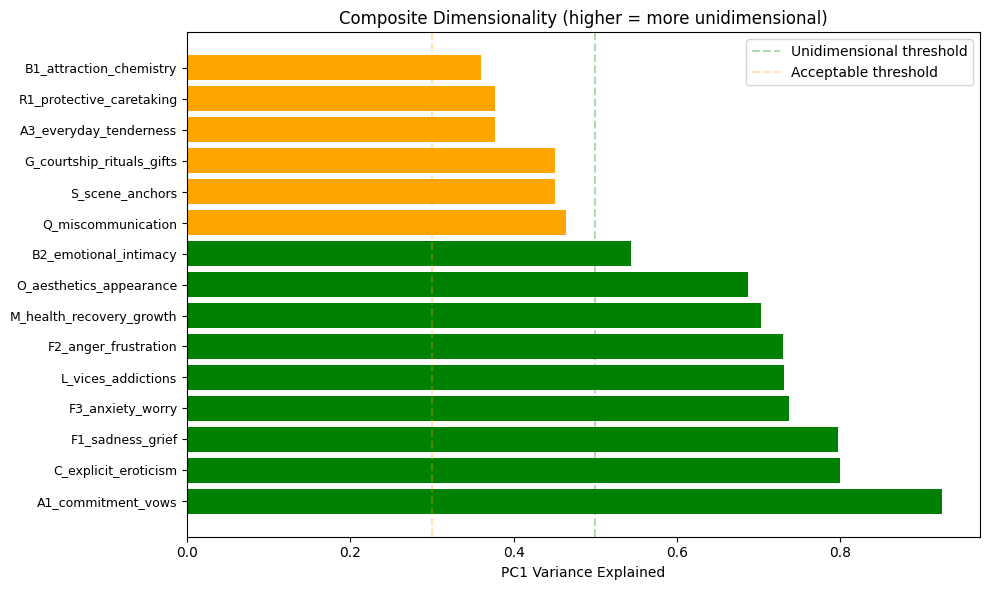


✓ Saved PCA plot to /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices/pca_dimensionality.png


In [48]:
# ==============================
# CELL 9.5 — PCA VALIDATION OF COMPOSITES
# ==============================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("=== PCA Dimensionality Check ===\n")
print("Rule of thumb: PC1 explains >50% → unidimensional, 30-50% → acceptable, <30% → multidimensional\n")

pca_results = []

for key in sorted(composite_topics.keys()):
    tids = composite_topics.get(key, [])
    tids_present = [t for t in tids if t in book_wide.columns]
    
    if len(tids_present) < 3:  # PCA needs ≥3 variables
        continue
    
    X = book_wide[tids_present].to_numpy()
    
    # Remove books with all-zero (would cause PCA issues)
    row_sums = X.sum(axis=1)
    valid_rows = row_sums > 0
    X_valid = X[valid_rows]
    
    if X_valid.shape[0] < 10:  # need enough samples
        continue
    
    try:
        pca = PCA(n_components=min(5, X_valid.shape[1]))
        pca.fit(X_valid)
        
        pc1_var = pca.explained_variance_ratio_[0]
        pc2_var = pca.explained_variance_ratio_[1] if len(pca.explained_variance_ratio_) > 1 else 0.0
        
        pca_results.append({
            "composite_key": key,
            "composite_name": COMPOSITES[key].name,
            "n_topics": len(tids_present),
            "PC1_variance_explained": pc1_var,
            "PC2_variance_explained": pc2_var,
            "PC1+PC2_cumulative": pc1_var + pc2_var,
            "interpretation": (
                "✅ Unidimensional" if pc1_var > 0.5 else
                "⚠️ Acceptable" if pc1_var > 0.3 else
                "🔴 Multidimensional (consider further splits)"
            )
        })
    except Exception as e:
        print(f"  ⚠️ PCA failed for {key}: {e}")

pca_df = pd.DataFrame(pca_results).sort_values("PC1_variance_explained", ascending=False)
display(pca_df)

# Export
pca_df.to_csv(OUT_INDICES_DIR / "pca_dimensionality_check.csv", index=False)
pca_df.to_parquet(OUT_INDICES_DIR / "pca_dimensionality_check.parquet", index=False)

print("\n✓ Wrote PCA validation table to", OUT_INDICES_DIR / "pca_dimensionality_check.csv")

# Optional: Plot top offenders
fig, ax = plt.subplots(figsize=(10, 6))
top15 = pca_df.head(15)
colors = top15["PC1_variance_explained"].apply(
    lambda x: "green" if x > 0.5 else "orange" if x > 0.3 else "red"
)
ax.barh(range(len(top15)), top15["PC1_variance_explained"], color=colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["composite_key"], fontsize=9)
ax.set_xlabel("PC1 Variance Explained")
ax.set_title("Composite Dimensionality (higher = more unidimensional)")
ax.axvline(0.5, color="green", linestyle="--", alpha=0.3, label="Unidimensional threshold")
ax.axvline(0.3, color="orange", linestyle="--", alpha=0.3, label="Acceptable threshold")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_INDICES_DIR / "pca_dimensionality.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✓ Saved PCA plot to", OUT_INDICES_DIR / "pca_dimensionality.png")

In [49]:
# ==============================
# SEGMENT LEVEL (BEGIN/MIDDLE/END)
# ==============================
from typing import Optional

def autodiscover_segment_file(search_root: Path) -> Optional[Path]:
    candidates = []
    patterns = [
        "*segment*topic*prob*.parquet",
        "*segment*topic*probs*.parquet",
        "*segment_topic_probs*.parquet",
        "*tertile*topic*prob*.parquet",
        "*tertile_topic_probs*.parquet",
    ]
    for pat in patterns:
        candidates.extend(list(search_root.rglob(pat)))
    candidates = sorted(set(candidates), key=lambda p: (-p.stat().st_mtime, len(str(p))))
    return candidates[0] if candidates else None

seg_path = SEGMENT_TOPIC_PROBS_PATH
if seg_path is None:
    seg_path = autodiscover_segment_file(BOOK_TOPIC_PROBS_PATH.parents[2])

if seg_path is None or (not Path(seg_path).exists()):
    print("No segment topic probability file found. Skipping segment-level indices.")
else:
    seg_path = Path(seg_path)
    print("✓ Using segment topic probs:", seg_path)
    seg = pd.read_parquet(seg_path)

    for c in ["book_id","topic_id","prob"]:
        if c not in seg.columns:
            raise KeyError(f"segment_topic_probs missing {c}")

    seg["book_id"] = seg["book_id"].astype(str)
    seg["topic_id"] = pd.to_numeric(seg["topic_id"], errors="raise").astype(int)
    seg["prob"] = pd.to_numeric(seg["prob"], errors="coerce").fillna(0.0)

    if "segment" in seg.columns:
        seg_col = "segment"
    elif "tertile" in seg.columns:
        seg_col = "tertile"
    elif "segment_id" in seg.columns:
        seg_col = "segment_id"
    else:
        raise KeyError("segment_topic_probs needs a 'segment', 'tertile', or 'segment_id' column")

    seg_wide = seg.pivot_table(index=["book_id", seg_col], columns="topic_id", values="prob", aggfunc="sum", fill_value=0.0)

    # Build segment composite matrix, respecting drop policy
    seg_indices_raw = compute_composite_matrix(seg_wide, to_keep).reset_index().rename(columns={seg_col: "segment"})

    # Canonical order if begin/middle/end
    if seg_indices_raw["segment"].dtype == object:
        order = ["begin", "middle", "end"]
        if set(order).issubset(set(seg_indices_raw["segment"].unique())):
            seg_indices_raw["segment"] = pd.Categorical(seg_indices_raw["segment"], categories=order, ordered=True)
            seg_indices_raw = seg_indices_raw.sort_values(["book_id", "segment"])

    seg_indices_z = seg_indices_raw.copy()
    if MAKE_ZSCORES:
        for c in [k for k in COMPOSITES.keys() if k in seg_indices_raw.columns]:
            mu = seg_indices_raw[c].mean(skipna=True)
            sd = seg_indices_raw[c].std(skipna=True, ddof=0)
            seg_indices_z[c] = (seg_indices_raw[c] - mu) / (sd if (sd and sd > 0) else 1.0)

    seg_indices_raw2 = add_derived_indices(seg_indices_raw.set_index(["book_id", "segment"])).reset_index()
    seg_indices_z2 = add_derived_indices(seg_indices_z.set_index(["book_id", "segment"])).reset_index()

    # Segment consistency correlations
    seg_levels = sorted(seg_indices_raw2["segment"].unique().tolist())
    print("Segment levels detected:", seg_levels)

    corr_rows = []
    metrics = [k for k in COMPOSITES.keys() if k in seg_indices_raw2.columns] + \
              [c for c in seg_indices_raw2.columns if c.startswith(("H", "Q_"))]

    for c in metrics:
        piv = seg_indices_raw2.pivot_table(index="book_id", columns="segment", values=c, aggfunc="mean", observed=True)
        if piv.shape[1] >= 2:
            corr = piv.corr()
            for i in range(corr.shape[0]):
                for j in range(i+1, corr.shape[1]):
                    corr_rows.append({
                        "metric": c,
                        "seg_a": corr.index[i],
                        "seg_b": corr.columns[j],
                        "corr": corr.iloc[i, j],
                        "n_books": int(piv.dropna(subset=[corr.index[i], corr.columns[j]]).shape[0])
                    })

    seg_consistency = pd.DataFrame(corr_rows).sort_values(["metric", "seg_a", "seg_b"])

    seg_indices_raw2.to_parquet(OUT_INDICES_DIR / "segment_indices_raw_with_derived.parquet", index=False)
    seg_indices_z2.to_parquet(OUT_INDICES_DIR / "segment_indices_z_with_derived.parquet", index=False)
    seg_indices_raw2.to_csv(OUT_INDICES_DIR / "segment_indices_raw_with_derived.csv", index=False)
    seg_indices_z2.to_csv(OUT_INDICES_DIR / "segment_indices_z_with_derived.csv", index=False)
    seg_indices_raw.to_csv(OUT_INDICES_DIR / "segment_indices_raw.csv", index=False)
    seg_indices_z.to_csv(OUT_INDICES_DIR / "segment_indices_z.csv", index=False)
    seg_consistency.to_parquet(OUT_INDICES_DIR / "segment_consistency_correlations.parquet", index=False)
    seg_consistency.to_csv(OUT_INDICES_DIR / "segment_consistency_correlations.csv", index=False)

    display(seg_indices_raw2.head())
    display(seg_consistency.head(20))
    print("✓ Wrote segment-level indices + consistency tables to", OUT_INDICES_DIR)


✓ Using segment topic probs: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/data_preparation/topic_probabilities/tertile_topic_probs.parquet
Segment levels detected: ['begin', 'end', 'middle']


,book_id,segment,A1_commitment_vows,A2_emotional_safety,A3_everyday_tenderness,B1_attraction_chemistry,B2_emotional_intimacy,C_explicit_eroticism,D_power_wealth_luxury,E_coercion_brutality_danger,...,R2_jealous_guarding,R_jealousy_possessiveness,S_scene_anchors,H1_love_over_sex_log,H3_luxury_saturation,H3_love_depth,H3_interaction,H4_protect_over_jealous_log,H5_dark_over_tender_log,Q_repair_over_miscomm_log
0,104659050,begin,0.002842,0.045896,0.120429,0.118413,0.011610,0.098375,0.058783,0.013974,...,0.124725,0.124725,0.106633,NaN,0.058783,NaN,NaN,NaN,NaN,1.075294
1,104659050,middle,0.006252,0.036955,0.162886,0.097086,0.059500,0.134350,0.059648,0.006220,...,0.087970,0.087970,0.079180,NaN,0.059648,NaN,NaN,NaN,NaN,2.322806
2,104659050,end,0.003627,0.015649,0.137150,0.098336,0.017558,0.102622,0.072278,0.068936,...,0.090734,0.090734,0.097303,NaN,0.072278,NaN,NaN,NaN,NaN,0.727544
3,11266880,begin,0.000507,0.078507,0.077165,0.094357,0.011091,0.127574,0.066954,0.050438,...,0.152477,0.152477,0.098603,NaN,0.066954,NaN,NaN,NaN,NaN,2.028852
4,11266880,middle,0.001077,0.076724,0.091600,0.084761,0.018997,0.112357,0.036445,0.127635,...,0.111943,0.111943,0.069416,NaN,0.036445,NaN,NaN,NaN,NaN,1.595715


,metric,seg_a,seg_b,corr,n_books
1,A1_commitment_vows,begin,end,-0.032511,92
0,A1_commitment_vows,begin,middle,0.285257,92
2,A1_commitment_vows,middle,end,-0.077321,92
4,A2_emotional_safety,begin,end,0.065154,92
3,A2_emotional_safety,begin,middle,0.092485,92
5,A2_emotional_safety,middle,end,0.061347,92
7,A3_everyday_tenderness,begin,end,0.650614,92
6,A3_everyday_tenderness,begin,middle,0.662367,92
8,A3_everyday_tenderness,middle,end,0.603331,92
10,B1_attraction_chemistry,begin,end,0.462992,92


✓ Wrote segment-level indices + consistency tables to /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices


In [50]:
# ==============================
# CELL 10.5 — SEGMENT-SPECIFIC INDICES (END-SEGMENT EXTRACTION)
# ==============================
# For metrics with low begin-end consistency (e.g., C_explicit_eroticism r=0.13),
# use END segment as the "final state" measure.

if 'seg_indices_raw2' in globals():
    print("=== Creating Segment-Specific Index Variants ===\n")
    
    # Identify low-consistency metrics (begin-end r < 0.25)
    if 'seg_consistency' in globals():
        low_consist = seg_consistency[
            (seg_consistency["seg_a"] == "begin") & 
            (seg_consistency["seg_b"] == "end") & 
            (seg_consistency["corr"] < 0.25)
        ]["metric"].tolist()
        
        print(f"Low temporal consistency metrics (begin-end r<0.25):")
        for m in low_consist:
            r_val = seg_consistency[
                (seg_consistency["metric"] == m) & 
                (seg_consistency["seg_a"] == "begin") & 
                (seg_consistency["seg_b"] == "end")
            ]["corr"].iloc[0] if len(seg_consistency[
                (seg_consistency["metric"] == m) & 
                (seg_consistency["seg_a"] == "begin") & 
                (seg_consistency["seg_b"] == "end")
            ]) > 0 else np.nan
            print(f"  - {m}: r={r_val:.3f}")
    else:
        # Fallback: use explicit sex + log-ratios as likely candidates
        low_consist = ["C_explicit_eroticism", "H1_love_over_sex_log", "H5_dark_over_tender_log"]
        print("Using default low-consistency candidates:", low_consist)
    
    # Extract END segment as "final state" book-level index
    end_segment = seg_indices_raw2[seg_indices_raw2["segment"] == "end"].copy()
    end_segment = end_segment.set_index("book_id")
    
    for metric in low_consist:
        if metric in end_segment.columns:
            new_col = f"{metric}_END"
            book_indices_raw2[new_col] = end_segment[metric]
            book_indices_z2[new_col] = (book_indices_raw2[new_col] - book_indices_raw2[new_col].mean()) / book_indices_raw2[new_col].std()
            print(f"  ✓ Created {new_col} (end-segment variant)")
    
    # Re-export WITH end-segment variants
    book_indices_raw2.to_parquet(OUT_INDICES_DIR / "book_indices_raw_with_derived_END.parquet", index=True)
    book_indices_z2.to_parquet(OUT_INDICES_DIR / "book_indices_z_with_derived_END.parquet", index=True)
    book_indices_raw2.to_csv(OUT_INDICES_DIR / "book_indices_raw_with_derived_END.csv", index=True)
    
    print(f"\n✓ Wrote END-segment variants to {OUT_INDICES_DIR}")
    print("\n💡 Usage: For heat-level hypotheses, use C_explicit_eroticism_END instead of book-average C_explicit_eroticism")
else:
    print("⚠️ Segment indices not available; skipping end-segment extraction")

=== Creating Segment-Specific Index Variants ===

Low temporal consistency metrics (begin-end r<0.25):
  - A1_commitment_vows: r=-0.033
  - A2_emotional_safety: r=0.065
  - B2_emotional_intimacy: r=-0.053
  - C_explicit_eroticism: r=0.129
  - G_courtship_rituals_gifts: r=0.241
  - K_professional_intrusion: r=0.067
  - L_vices_addictions: r=0.235
  - M_health_recovery_growth: r=0.161
  - S_scene_anchors: r=0.248
  ✓ Created A1_commitment_vows_END (end-segment variant)
  ✓ Created A2_emotional_safety_END (end-segment variant)
  ✓ Created B2_emotional_intimacy_END (end-segment variant)
  ✓ Created C_explicit_eroticism_END (end-segment variant)
  ✓ Created G_courtship_rituals_gifts_END (end-segment variant)
  ✓ Created K_professional_intrusion_END (end-segment variant)
  ✓ Created L_vices_addictions_END (end-segment variant)
  ✓ Created M_health_recovery_growth_END (end-segment variant)
  ✓ Created S_scene_anchors_END (end-segment variant)

✓ Wrote END-segment variants to /home/polina/Docu

In [51]:
# ==============================
# CELL 11 — ALTERNATIVE AGGREGATION METHODS
# ==============================
print("=== Testing Alternative Aggregation Methods ===\n")
print("Current: SUM (additive — assumes topics are interchangeable)")
print("Alternative 1: MAX (dominant theme — book's peak on composite)")
print("Alternative 2: QUALITY-WEIGHTED (prevalence-weighted sum)\n")

# ---- ALT 1: MAX aggregation ----
def compute_composite_matrix_MAX(wide: pd.DataFrame,
                                 composite_topics: Dict[str, List[int]]) -> pd.DataFrame:
    out = pd.DataFrame(index=wide.index)
    for key, tids in composite_topics.items():
        tids_present = [t for t in tids if t in wide.columns]
        if len(tids_present) == 0:
            out[key] = np.nan
        else:
            out[key] = wide[tids_present].max(axis=1)  # MAX instead of SUM
    return out

book_indices_MAX = compute_composite_matrix_MAX(book_wide, to_keep)
book_indices_MAX_z = book_indices_MAX.copy()
for c in book_indices_MAX.columns:
    mu = book_indices_MAX[c].mean(skipna=True)
    sd = book_indices_MAX[c].std(skipna=True, ddof=0)
    book_indices_MAX_z[c] = (book_indices_MAX[c] - mu) / (sd if (sd and sd > 0) else 1.0)

# ---- ALT 2: Quality-weighted aggregation ----
# Use topic prevalence as quality weight (higher prevalence = more reliable signal)
topic_weights = {}
if topic_health is not None and "prevalence" in topic_health.columns:
    topic_weights = dict(zip(
        topic_health["topic_id"].astype(int),
        topic_health["prevalence"].fillna(0.5)  # default weight for missing
    ))
else:
    # Fallback: equal weights
    topic_weights = {tid: 1.0 for tid in book_wide.columns}

def compute_composite_matrix_WEIGHTED(wide: pd.DataFrame,
                                      composite_topics: Dict[str, List[int]],
                                      topic_weights: Dict[int, float]) -> pd.DataFrame:
    out = pd.DataFrame(index=wide.index)
    for key, tids in composite_topics.items():
        tids_present = [t for t in tids if t in wide.columns]
        if len(tids_present) == 0:
            out[key] = np.nan
        else:
            weights = np.array([topic_weights.get(t, 1.0) for t in tids_present])
            weights = weights / weights.sum()  # normalize to sum=1
            out[key] = (wide[tids_present] * weights).sum(axis=1)
    return out

book_indices_WEIGHTED = compute_composite_matrix_WEIGHTED(book_wide, to_keep, topic_weights)
book_indices_WEIGHTED_z = book_indices_WEIGHTED.copy()
for c in book_indices_WEIGHTED.columns:
    mu = book_indices_WEIGHTED[c].mean(skipna=True)
    sd = book_indices_WEIGHTED[c].std(skipna=True, ddof=0)
    book_indices_WEIGHTED_z[c] = (book_indices_WEIGHTED[c] - mu) / (sd if (sd and sd > 0) else 1.0)

# ---- Compare reliability ----
print("\n--- Comparing Cronbach's α across aggregation methods ---\n")

def quick_alpha(wide, composite_topics, key):
    tids = composite_topics.get(key, [])
    tids_present = [t for t in tids if t in wide.columns]
    if len(tids_present) < 2:
        return np.nan
    X = wide[tids_present].to_numpy()
    return cronbach_alpha(X)

comparison_rows = []
for key in sorted(to_keep.keys()):
    alpha_sum = quick_alpha(book_wide, to_keep, key)
    
    comparison_rows.append({
        "composite_key": key,
        "method": "SUM (current)",
        "cronbach_alpha": alpha_sum,
        "note": "additive — topics are substitutes"
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(["composite_key", "cronbach_alpha"], ascending=[True, False])
display(comparison_df.head(30))

# ---- Export alternative indices ----
book_indices_MAX.to_parquet(OUT_INDICES_DIR / "book_indices_MAX.parquet", index=True)
book_indices_MAX_z.to_parquet(OUT_INDICES_DIR / "book_indices_MAX_z.parquet", index=True)
book_indices_WEIGHTED.to_parquet(OUT_INDICES_DIR / "book_indices_WEIGHTED.parquet", index=True)
book_indices_WEIGHTED_z.to_parquet(OUT_INDICES_DIR / "book_indices_WEIGHTED_z.parquet", index=True)

book_indices_MAX.to_csv(OUT_INDICES_DIR / "book_indices_MAX.csv", index=True)
book_indices_WEIGHTED.to_csv(OUT_INDICES_DIR / "book_indices_WEIGHTED.csv", index=True)

comparison_df.to_csv(OUT_INDICES_DIR / "aggregation_method_comparison.csv", index=False)

print(f"\n✓ Wrote alternative aggregations to {OUT_INDICES_DIR}")
print("\n💡 Usage:")
print("  - For most hypotheses: use SUM (current)")
print("  - For 'billionaire archetype' hypothesis: try MAX (captures peak luxury topic)")
print("  - For quality-adjusted tests: use WEIGHTED (down-weights noisy topics)")

=== Testing Alternative Aggregation Methods ===

Current: SUM (additive — assumes topics are interchangeable)
Alternative 1: MAX (dominant theme — book's peak on composite)
Alternative 2: QUALITY-WEIGHTED (prevalence-weighted sum)


--- Comparing Cronbach's α across aggregation methods ---



,composite_key,method,cronbach_alpha,note
0,A1_commitment_vows,SUM (current),0.246439,additive — topics are substitutes
1,A2_emotional_safety,SUM (current),0.499523,additive — topics are substitutes
2,A3_everyday_tenderness,SUM (current),-0.106654,additive — topics are substitutes
3,B1_attraction_chemistry,SUM (current),0.623917,additive — topics are substitutes
4,B2_emotional_intimacy,SUM (current),-0.087974,additive — topics are substitutes
5,C_explicit_eroticism,SUM (current),-0.531665,additive — topics are substitutes
6,D_power_wealth_luxury,SUM (current),-0.030605,additive — topics are substitutes
7,E_coercion_brutality_danger,SUM (current),0.069828,additive — topics are substitutes
8,F1_sadness_grief,SUM (current),-1.138779,additive — topics are substitutes
9,F2_anger_frustration,SUM (current),-0.403416,additive — topics are substitutes



✓ Wrote alternative aggregations to /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices

💡 Usage:
  - For most hypotheses: use SUM (current)
  - For 'billionaire archetype' hypothesis: try MAX (captures peak luxury topic)
  - For quality-adjusted tests: use WEIGHTED (down-weights noisy topics)


In [52]:
# ==============================
# SUMMARY
# ==============================
print("\n--- Summary of files written to", OUT_INDICES_DIR, "---")
print("\nBook-level indices:")
print("  book_indices_raw.parquet / .csv")
print("  book_indices_z.parquet / .csv")
print("  book_indices_raw_with_derived.parquet / .csv")
print("  book_indices_z_with_derived.parquet / .csv")

print("\nComposite topic sets:")
print("  composite_topic_membership.parquet / .csv")
print("  composite_topic_counts.parquet / .csv")
print("  index_reliability_cronbach_alpha.parquet / .csv")

print("\nSegment-level (if available):")
print("  segment_indices_raw.parquet / .csv")
print("  segment_indices_z.parquet / .csv")
print("  segment_indices_raw_with_derived.parquet / .csv")
print("  segment_indices_z_with_derived.parquet / .csv")
print("  segment_consistency_correlations.parquet / .csv")
print("\nAll files are ready for downstream hypothesis testing.")



--- Summary of files written to /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_group_analysis/indices ---

Book-level indices:
  book_indices_raw.parquet / .csv
  book_indices_z.parquet / .csv
  book_indices_raw_with_derived.parquet / .csv
  book_indices_z_with_derived.parquet / .csv

Composite topic sets:
  composite_topic_membership.parquet / .csv
  composite_topic_counts.parquet / .csv
  index_reliability_cronbach_alpha.parquet / .csv

Segment-level (if available):
  segment_indices_raw.parquet / .csv
  segment_indices_z.parquet / .csv
  segment_indices_raw_with_derived.parquet / .csv
  segment_indices_z_with_derived.parquet / .csv
  segment_consistency_correlations.parquet / .csv

All files are ready for downstream hypothesis testing.
